# Causal interventions inside GraphCast — demo

This notebook regenerates the paper's headline figures and tables from the result
files shipped in this package. Everything here runs on **CPU in a few minutes**;
the GPU experiments that *produced* the result files are in `graphcast_sae/`
(each script's docstring gives its exact invocation).

Contents:
1. **Hurricane Ida** — each genesis ingredient dialled up 2×, watched on the model's internal cyclone feature (+12/+24/+36/+48 h).
2. **Seven storms** — ablation of each calibrated mechanism group, scored as lost deepening against ERA5.
3. **Amplification** — the convection gain sweep on Ida, Haishen, Patricia: the forecast gets *better*, with an optimum.
4. **Grid-locked features** — the mesh-keyed features on a map, their ablation costs, and why "looks like an artifact" does not predict "removable".

In [1]:
import json, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import griddata

ROOT = pathlib.Path.cwd()
if not (ROOT / "results").exists(): ROOT = ROOT.parent   # kernel started inside notebooks/
RES, DATA = ROOT / "results", ROOT / "data"

geom = np.load(DATA / "mesh_2to6_geom.npy", allow_pickle=True).item()
MLAT = geom["lat"]
MLON = np.where(geom["lon"] > 180, geom["lon"] - 360, geom["lon"])

_lsm = np.load(RES / "land_sea_mask_025.npz")
_lo = np.where(_lsm["lon"] > 180, _lsm["lon"] - 360, _lsm["lon"])
_o = np.argsort(_lo)
LSM, LSM_LAT, LSM_LON = _lsm["lsm"][:, _o], _lsm["lat"], _lo[_o]

def coast(ax, color="#888888", lw=0.5):
    ax.contour(LSM_LON, LSM_LAT, LSM, levels=[0.5], colors=[color], linewidths=lw)

def nodemap(vals, lat_rng=(-90, 90), lon_rng=(-180, 180), step=1.0):
    glon = np.arange(lon_rng[0], lon_rng[1] + .01, step)
    glat = np.arange(lat_rng[0], lat_rng[1] + .01, step)
    G = griddata((MLON, MLAT), vals, tuple(np.meshgrid(glon, glat)), method="linear")
    return glon, glat, np.nan_to_num(G, nan=0.0)

print(f"mesh nodes: {len(MLAT):,}   package root: {ROOT.name}")

mesh nodes: 40,962   package root: causal-graphcast-repro


## 1 · Hurricane Ida — dial up each ingredient

A 48-h rollout from **2021-08-26 00Z**, the two days Ida organised over the
Caribbean. The readout is GraphCast's *internal* cyclone feature (SAE feature
f3243, layer 8). Top row: the untouched forecast igniting. Each row below
replays the identical rollout with one mechanism's features doubled wherever
they fire; the leftmost maps show where that group's features fire (baseline, +30h).

Groups are the strongest **rotation-null-calibrated** members of each mechanism that
fire on Ida (`results/fs_mechanisms_v2.npy`): convection f2401 f2067 f3174 (ascent,
+21 to +29σ), low-level spin f2089 f2514 f3316 (vort850), mid-level moisture f2415 f3780
f1829 (q600), shear f1996 f3460. An earlier version of this panel used groups from an
uncalibrated labeller; its "moisture" group was weak ascent and its "vorticity" group was
three polar features that barely fire on Ida (`docs/notes/result_ida_genesis_calibrated_2026_08_29.md`).
Produced by `graphcast_sae/storms/ida_mechmaps_prog.py` (`MECHMAPS_TAG=_v2`).


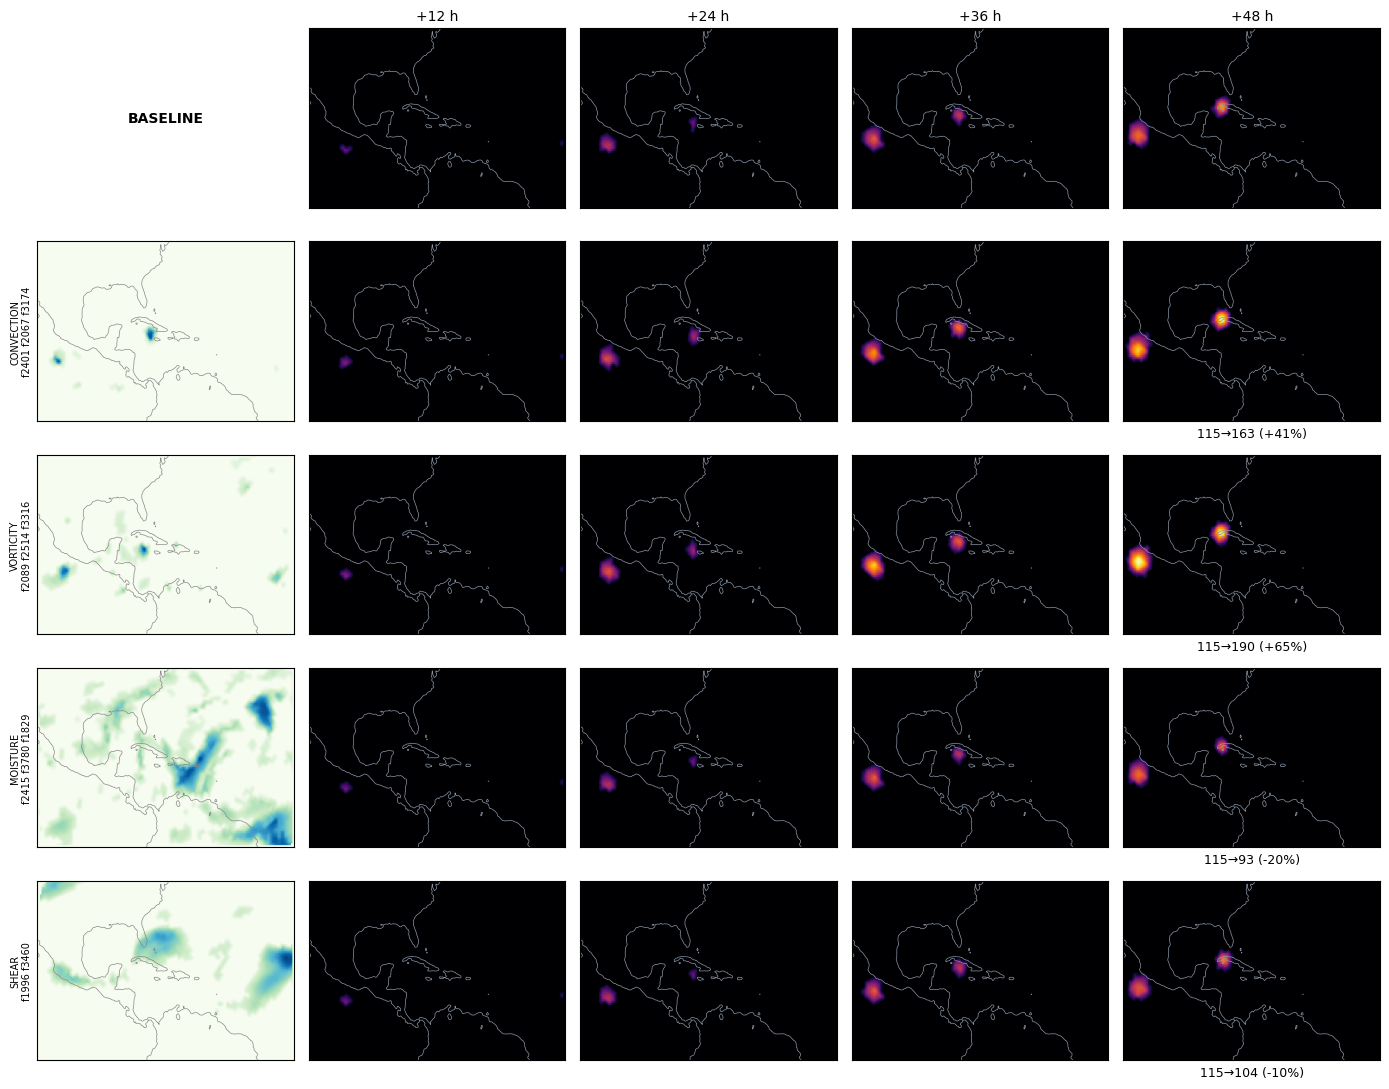

In [2]:
d = np.load(RES / "fs_ida_mechmaps_prog_v2.npy", allow_pickle=True).item()
reg, leads, MECH = d["reg"], d["leads"], d["mech"]
nl = MLAT >= -999  # unused; node subset stored in file
mlat_s, mlon_s = d["mlat"], d["mlon"]

def boxmap(v):
    glon = np.arange(reg["lon"][0], reg["lon"][1] + .01, 0.4)
    glat = np.arange(reg["lat"][0], reg["lat"][1] + .01, 0.4)
    G = griddata((mlon_s, mlat_s), v, tuple(np.meshgrid(glon, glat)), method="linear")
    return np.nan_to_num(G, nan=0.0)

vmax = max(float(np.max(d[k][l])) for l in leads
           for k in ["tc_base"] + [f"tc_{m}" for m in MECH])
rows = ["baseline", "convection", "vorticity", "moisture", "shear"]
fig, axes = plt.subplots(len(rows), 5, figsize=(14, 11))
for i, row in enumerate(rows):
    ax = axes[i, 0]
    if row == "baseline":
        ax.axis("off"); ax.text(.5, .5, "BASELINE", ha="center",
                                va="center", transform=ax.transAxes, weight="bold")
    else:
        ax.imshow(boxmap(d["mech_map"][row]), origin="lower",
                  extent=[*reg["lon"], *reg["lat"]], cmap="GnBu", aspect="auto")
        coast(ax); ax.set_xlim(*reg["lon"]); ax.set_ylim(*reg["lat"])
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_ylabel(f"{row.upper()}\n" + " ".join(f"f{f}" for f in MECH[row]),
                      fontsize=7)
    key = "tc_base" if row == "baseline" else f"tc_{row}"
    for j, lead in enumerate(leads):
        ax = axes[i, j + 1]
        ax.imshow(boxmap(d[key][lead]), origin="lower", extent=[*reg["lon"], *reg["lat"]],
                  cmap="inferno", vmin=0, vmax=vmax, aspect="auto")
        coast(ax, "#8a97a5"); ax.set_xlim(*reg["lon"]); ax.set_ylim(*reg["lat"])
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0: ax.set_title(f"+{lead} h", fontsize=10)
    if row != "baseline":
        s48, b48 = float(np.sum(d[key][48])), float(np.sum(d["tc_base"][48]))
        axes[i, 4].set_xlabel(f"{b48:.0f}→{s48:.0f} ({100*(s48-b48)/b48:+.0f}%)", fontsize=9)
plt.tight_layout(); plt.show()

## 2 · Seven storms — mechanism ablations against ERA5

Each calibrated feature group is **restored to a quiet-day normal level** inside a
1500 km disk around the storm through a 96-h rollout (delete-to-zero shown for the
convection arm as the upper bound). The cost is the share of the storm's real
deepening the forecast loses. Groups and their calibrated labels: convection
(f2401 f2067 f3174, 3/3 ascent), low-level spin (f2089 f2514 f3316, 3/3 vort850 — and
the storm-core feature f3316 alone), mid-level moisture (f2958 f2671 f37, 3/3 q600).
Noise floor of this protocol: ±0.06 hPa per cell; run-to-run floor on min-MSLP: median 0.15 hPa.
Produced by `graphcast_sae/storms/skill_conv_run.py` (`results/skill/*/verdict.json`).


In [3]:
def arm_pct(metrics, storm, arm):
    b = metrics[storm]["arms"]["baseline"]["deepen"]
    return 100.0 * metrics[storm]["arms"][arm]["d_deepen"] / b

conv = json.load(open(RES / "skill/convection/verdict.json"))["metrics"]
spin = json.load(open(RES / "skill/mech_spin3316/verdict.json"))["metrics"]
one  = json.load(open(RES / "skill/mech_3316/verdict.json"))["metrics"]
mois = json.load(open(RES / "skill/moisture2/verdict.json"))["metrics"]
storms = [s for s in conv if "arms" in conv[s] and "nondev" not in s]
rows = []
for s in sorted(storms):
    b = conv[s]["arms"]["baseline"]["deepen"]
    rows.append({
        "storm": s, "GraphCast deepening (hPa)": round(b, 1),
        "conv → normal (%)": round(arm_pct(conv, s, "conv-normal"), 1),
        "conv → zero (%)": round(arm_pct(conv, s, "conv-zero"), 1),
        "spin → normal (%)": round(arm_pct(spin, s, "conv-normal"), 1),
        "f3316 alone → normal (%)": round(arm_pct(one, s, "conv-normal"), 1),
        "moisture → normal (%)": round(arm_pct(mois, s, "conv-normal"), 1)
            if s in mois and "conv-normal" in mois[s]["arms"] else np.nan,
        "random ctrl (%)": round(arm_pct(conv, s, "rand-normal"), 1),
    })
t = pd.DataFrame(rows).set_index("storm")
t.loc["MEDIAN"] = t.median()
t


,GraphCast deepening (hPa),conv → normal (%),conv → zero (%),spin → normal (%),f3316 alone → normal (%),moisture → normal (%),random ctrl (%)
storm,,,,,,,
goni2020,12.5,17.2,28.5,35.5,28.1,-0.5,3.0
haishen2020,26.3,28.4,65.1,2.9,3.7,-0.5,-0.4
haiyan2013,22.5,33.3,40.7,13.3,6.3,0.9,-0.7
ida2021,6.8,41.1,50.9,116.3,109.2,-0.5,0.7
michael2018,11.5,18.7,36.1,29.0,26.2,-0.1,1.4
patricia2015,5.5,3.7,16.4,38.8,35.1,0.2,0.2
wilma2005,22.9,19.2,45.9,40.3,32.1,-2.4,-0.5
MEDIAN,12.5,19.2,40.7,35.5,28.1,-0.5,0.2


Two levers, not one. Convection costs a median **19%** of real deepening under the
honest restore-to-normal counterfactual (41% on Ida, up to 51% delete-to-zero);
the low-level-spin group costs **36%** (2089/2514/3316: 3.30 hPa median against
convection's 2.79), and ~90% of that is the single storm-core feature f3316
(2.95 hPa alone). Both have the same sign on all seven storms. The
firing-rate-matched random control and the genuinely-calibrated moisture group sit
at the noise floor. f3316 fires 12–24 h *before* the cyclone feature in every storm
that forms inside the rollout, and on the non-developing wave: it is a precursor
(the seed vortex), not the cyclone under another name.


## 3 · Amplification — the gain sweeps

The converse intervention: multiply a feature group by a gain g ≥ 1 inside the storm
disk. Prediction (pre-registered): if the group is a causal carrier, amplifying it
should *reduce* the intensity error against ERA5, most on storms where ablation cost
most, with an optimum and punished overshoot. Two sweeps: the convection triplet
(`results/skill/gain_conv/`) and the spin feature f3316 (`results/skill/gain_3316/`,
`docs/prereg/prereg_gain_3316.md`). Produced by `graphcast_sae/storms/skill_conv_run.py` (`MECH_GAINS`).


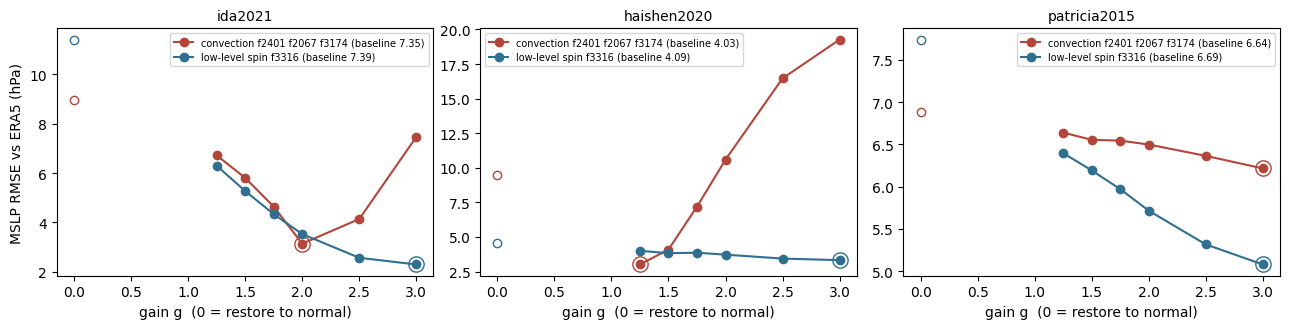

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=False)
for ax, storm in zip(axes, ("ida2021", "haishen2020", "patricia2015")):
    for arm, col, lab in (("gain_conv", "#B3453A", "convection f2401 f2067 f3174"),
                          ("gain_3316", "#2f6f8f", "low-level spin f3316")):
        truth = np.load(RES / f"skill/{arm}/era5_truth.npy", allow_pickle=True).item()
        d = np.load(RES / f"skill/{arm}/run_{storm}.npy", allow_pickle=True).item()
        tr = np.asarray(truth[storm]["mslp_min"], float)
        win = max(int(np.argmin(tr)), 6) + 1          # intensification window (as the paper figure)
        def rmse(a):
            m = np.asarray(d["res"][a]["mslp_min"], float); n = min(win, len(m), len(tr))
            return float(np.sqrt(np.mean((m[:n] - tr[:n]) ** 2)))
        gains = sorted(float(k.split("-", 1)[1]) for k in d["res"] if k.startswith("gain-"))
        r = np.array([rmse("gain-%g" % g) for g in gains]); base = rmse("baseline")
        g = np.array(gains)
        ax.plot(g[g >= 1], r[g >= 1], "o-", color=col, label=f"{lab} (baseline {base:.2f})")
        ax.plot(g[g == 0], r[g == 0], "o", mfc="none", mec=col)
        i = int(np.argmin(r[g >= 1])); ax.plot(g[g >= 1][i], r[g >= 1][i], "o", ms=11, mfc="none", mec=col)
    ax.set_title(storm, fontsize=10); ax.set_xlabel("gain g  (0 = restore to normal)"); ax.legend(fontsize=7)
axes[0].set_ylabel("MSLP RMSE vs ERA5 (hPa)")
plt.tight_layout(); plt.show()


Convection: Ida (ablation cost 41%) improves 7.35 → 3.13 hPa at g = 2.0 and Haishen
4.03 → 3.01 at g = 1.25, then both overshoot (Haishen to 19 hPa at g = 3); Patricia,
whose convection ablation was null, barely moves. The spin feature f3316 behaves
differently: every storm improves **monotonically through g = 3** with no overshoot
inside the sweep (Ida 7.39 → 2.29, Haishen 4.09 → 3.33, Patricia 6.69 → 5.08). The
random group at g = 3 moves the forecast by ≤ 0.05 hPa.


## 4 · Grid-locked features

Some SAE features do not look like weather: lattices of isolated dots on the
coarse icosahedral skeleton, filled bowties with straight edges. **Grid-lockedness**
= self-overlap of the active region across dates (weather features 0.01–0.12;
threshold 0.45). The obvious action — prune them — turns out to be wrong.

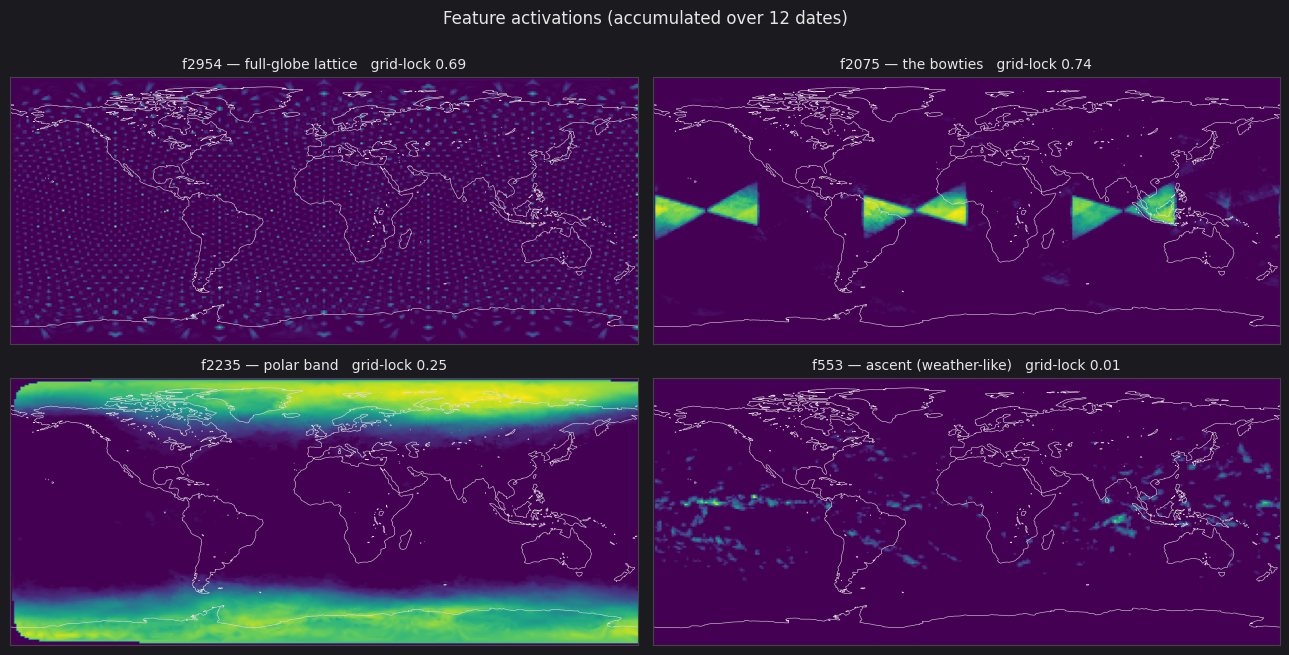

In [5]:
fp = np.load(DATA / "fs_footprint_fires_nw12.npz")
ACC = fp["acc"]
gl = np.load(RES / "fs_gridlock_all.npy", allow_pickle=True).item()
score = np.asarray(gl["score"], float)

show = [(2954, "f2954 — full-globe lattice"), (2075, "f2075 — the bowties"),
        (2235, "f2235 — polar band"), (553, "f553 — ascent (weather-like)")]
BG, FG = "#1b1b1f", "#e6e6e6"
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), facecolor=BG)
for ax, (f, name) in zip(axes.ravel(), show):
    lo, la, G = nodemap(ACC[:, f], step=1.2)
    ax.set_facecolor(BG)
    ax.imshow(G, origin="lower", extent=[-180, 180, -90, 90], cmap="viridis", aspect="auto")
    coast(ax, "#dddddd", 0.4)
    ax.set_title(f"{name}   grid-lock {score[f]:.2f}", fontsize=10, color=FG)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor("#444444")
fig.suptitle("Feature activations (accumulated over 12 dates)", y=1.0, color=FG)
plt.tight_layout(); plt.show()

### Ablation: single features against matched controls

Each feature is switched off (contribution set to its negative) for a whole
+48 h rollout on 6 start dates; the cost is extra global 500 hPa height error
against ERA5 (baseline ≈ 8.0 m; run-to-run floor ±0.017 m). Controls are matched
on coverage and fragmentation. Produced by `graphcast_sae/gridlock/global_rmse_ablate.py`
(`results/fs_perfeat_rmse.npy`, `fs_matched_rmse.npy`).

In [6]:
def arm_table(path, lead_step):
    d = np.load(path, allow_pickle=True).item()
    zi = d["fields"].index("z500")
    def pick(arm):
        a = d["acc"][arm]
        return a[:d["n"], lead_step, zi] if a.ndim == 3 else np.atleast_1d(a[lead_step, zi])
    base = pick("baseline")
    rows = []
    for arm in d["arms"]:
        if arm == "baseline": continue
        x = pick(arm)
        p = stats.ttest_rel(x, base).pvalue if len(x) > 1 else np.nan
        rows.append({"arm": arm, "extra z500 error (m)": x.mean() - base.mean(),
                     "as % of total": 100 * (x.mean() - base.mean()) / base.mean(),
                     "p (paired)": p})
    return pd.DataFrame(rows), base.mean()

pf, base48 = arm_table(RES / "fs_perfeat_rmse.npy", 7)
floor = pf[~pf["arm"].str.fullmatch(r"f\d+")]
if len(floor):
    print("floor arm (ablate nothing, pure rerun noise):",
          floor.iloc[0]["extra z500 error (m)"].round(4), "m")
pf = pf[pf["arm"].str.fullmatch(r"f\d+")].copy()
pf["feature"] = pf["arm"].str.replace("f", "", 1).astype(int)
pf["grid-lockedness"] = pf["feature"].map(lambda f: score[f])
pf = pf.sort_values("grid-lockedness", ascending=False)
pf = pf[["arm", "grid-lockedness", "extra z500 error (m)", "as % of total", "p (paired)"]]
print(f"baseline z500 RMSE at +48 h: {base48:.2f} m")
pf.round(3).reset_index(drop=True)

floor arm (ablate nothing, pure rerun noise): -0.0021 m
baseline z500 RMSE at +48 h: 8.02 m


,arm,grid-lockedness,extra z500 error (m),as % of total,p (paired)
0,f2075,0.743,0.032,0.400,0.011
1,f2954,0.690,1.487,18.537,0.001
2,f2651,0.516,0.008,0.095,0.259
3,f1079,0.277,-0.009,-0.116,0.371
4,f656,0.275,0.130,1.624,0.015
5,f3191,0.272,0.233,2.906,0.012
6,f2235,0.253,0.664,8.273,0.003
7,f3680,0.175,1.211,15.089,0.006
8,f560,0.171,0.726,9.045,0.001
9,f1089,0.115,0.016,0.193,0.084


In [7]:
grp, _ = arm_table(RES / "fs_global_rmse.npy", 7)
grp["n features"] = grp["arm"].map({"mesh_locked": 27, "ctrl_mesh": 27,
                                    "scatter_blob": 127, "ctrl_blob": 127})
ta, _ = arm_table(RES / "fs_global_rmse_topamp.npy", 7)
ta["n features"] = ta["arm"].map({"topamp_gl17": 17, "ctrl_topamp": 17, "topamp_wx3": 3})
pd.concat([grp, ta]).round(3).reset_index(drop=True)

,arm,extra z500 error (m),as % of total,p (paired),n features
0,mesh_locked,1.013,12.659,NaN,27
1,ctrl_mesh,0.854,10.677,NaN,27
2,scatter_blob,3.621,45.275,NaN,127
3,ctrl_blob,14.657,183.242,NaN,127
4,topamp_gl17,45.595,570.272,0.000,17
5,ctrl_topamp,49.802,622.889,0.000,17
6,topamp_wx3,0.448,5.609,0.001,3


**The two findings.** (1) *Nothing here is removable*: across single-feature and
group ablations, no deletion improved the forecast on any start date — the
features that look most like architecture are doing real work (f2954 alone costs
+1.5 m, 19% of the whole two-day error). (2) *Looking like an artifact does not
predict mattering*: grid-lockedness ranks weakly with damage (ρ ≈ +0.36); the
largest effects come from pairs where both sides are the same class, and the
17 highest-amplitude grid-locked features cost about the same as a matched
weather-like set at +48 h (the class difference emerges only at longer leads).

---
### Number → file manifest

| paper number | source in this package |
|---|---|
| median 19% deepening lost (convection) | `results/skill/convection/verdict.json` |
| moisture group −0.03 hPa (null) | `results/skill/moisture2/verdict.json` |
| Ida gain optimum 7.35→3.13 @ g=2.0 | `results/skill/gain_conv/run_ida2021.npy` |
| Haishen optimum @ g=1.25 | `results/skill/gain_conv/run_haishen2020.npy` |
| f2954 +1.50 m (19% of z500 error) | `results/fs_perfeat_rmse.npy` / `fs_matched_rmse.npy` |
| mesh-locked group ≈ matched control | `results/fs_global_rmse.npy` |
| top-amplitude grid-locked arm | `results/fs_global_rmse_topamp.npy` |
| grid-lockedness scores (4,096 features) | `results/fs_gridlock_all.npy` |
| heat-dome ridge removal ladder | `results/heatdome/physics_verdict.json` |